<a href="https://colab.research.google.com/github/Ashik-13/PINNs/blob/main/1D_Wave_Equation_using_PINNs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1D Wave Equation Using Physics-Informed Neural Networks

## A Physics-Informed Deep Learning Approach for Solving the One-Dimensional Wave Equation

This notebook develops a Physics-Informed Neural Network (PINN) to solve the one-dimensional wave equation.

The objective is to construct a neural network that learns the wave field directly from:

1. The governing partial differential equation (PDE)
2. The initial displacement condition
3. The initial velocity condition
4. The boundary conditions

The trained PINN will then be compared against the analytical solution to quantitatively evaluate its accuracy.

### Governing Equation

The one-dimensional wave equation is

$$
\frac{\partial^2 u}{\partial t^2}
=
c^2
\frac{\partial^2 u}{\partial x^2}
$$

or equivalently,

$$
u_{tt}-c^2u_{xx}=0.
$$

where:

- $u(x,t)$ is the wave displacement,
- $x$ is the spatial coordinate,
- $t$ is time,
- $c$ is the wave propagation speed.

### Main Objective

The main goal of this notebook is to demonstrate a complete PINN workflow:

$$
\text{Physics}
\rightarrow
\text{Neural Network}
\rightarrow
\text{Automatic Differentiation}
\rightarrow
\text{Physics Loss}
\rightarrow
\text{Training}
\rightarrow
\text{Prediction}
\rightarrow
\text{Validation}
$$


## Problem Definition

We consider a one-dimensional vibrating string of length $L$.

The displacement of the string is represented by

$$
u(x,t).
$$

The spatial and temporal domains are defined as

$$
0\leq x\leq L
$$

and

$$
0\leq t\leq T.
$$

For this benchmark problem, we choose

$$
L=1
$$

and

$$
T=1.
$$

The wave speed is selected as

$$
c=1.
$$

Therefore, the governing equation becomes

$$
u_{tt}=u_{xx}.
$$

This problem has a known analytical solution, which allows us to rigorously validate the PINN prediction.

# Problem Parameters

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Spatial domain
L = 1.0

# Temporal domain
T = 1.0

# Wave propagation speed
c = 1.0

print(f"Spatial domain: x ∈ [0, {L}]")
print(f"Temporal domain: t ∈ [0, {T}]")
print(f"Wave speed: c = {c}")

Spatial domain: x ∈ [0, 1.0]
Temporal domain: t ∈ [0, 1.0]
Wave speed: c = 1.0


# Mathematical Formulation

### Governing Partial Differential Equation

The governing equation is

$$
u_{tt}-c^2u_{xx}=0.
$$

The PDE residual is therefore defined as

$$
r(x,t)
=
u_{tt}(x,t)-c^2u_{xx}(x,t).
$$

For an exact solution,

$$
r(x,t)=0
$$

everywhere inside the computational domain.

The PINN will be trained to minimize this residual.

### Initial Conditions

Because the wave equation contains a second-order derivative with respect to time, two initial conditions are required.

#### Initial displacement

We prescribe

$$
u(x,0)=\sin(\pi x).
$$

#### Initial velocity

The initial velocity is

$$
u_t(x,0)=0.
$$

Therefore, the string initially has a sinusoidal displacement and is released from rest.

### Boundary Conditions

We consider a string fixed at both ends.

Therefore,

$$ u(0,t)=0 $$

and

$$ u(1,t)=0. $$

These are homogeneous Dirichlet boundary conditions.

Physically, they represent a string whose two endpoints remain fixed during the entire simulation.

# <font color="blue=0.2">Analytical Solution</font>

To validate the Physics-Informed Neural Network (PINN), we derive the analytical solution of the one-dimensional wave equation corresponding to the selected initial and boundary conditions.

## Governing Wave Equation

The one-dimensional wave equation is

$$
\frac{\partial^2 u}{\partial t^2}
=
c^2
\frac{\partial^2 u}{\partial x^2},
$$

or equivalently,

$$
u_{tt}-c^2u_{xx}=0,
$$

where $c$ is the wave propagation speed.

For this problem, the spatial domain is

$$
0\leq x\leq L,
$$

and the temporal domain is

$$
t\geq0.
$$

We consider

$$
L=1.
$$

Therefore, the governing equation becomes

$$
u_{tt}=c^2u_{xx},
\qquad
0\leq x\leq1.
$$


## Initial and Boundary Conditions

The string is fixed at both ends, so the boundary conditions are

$$
u(0,t)=0,
$$

and

$$
u(1,t)=0.
$$

The initial displacement is

$$
u(x,0)=\sin(\pi x),
$$

and the initial velocity is

$$
u_t(x,0)=0.
$$

Therefore, the complete initial-boundary value problem is

$$
\boxed{
u_{tt}=c^2u_{xx}
}
$$

subject to

$$
\boxed{
u(0,t)=u(1,t)=0
}
$$

and

$$
\boxed{
u(x,0)=\sin(\pi x),
\qquad
u_t(x,0)=0.
}
$$


## Separation of Variables

To obtain the analytical solution, we assume that the solution can be written as a product of a spatial function and a temporal function:

$$
u(x,t)=X(x)T(t).
$$

Substituting this into the wave equation gives

$$
X(x)T''(t)
=
c^2X''(x)T(t).
$$

Dividing both sides by $c^2X(x)T(t)$ gives

$$
\frac{T''(t)}{c^2T(t)}
=
\frac{X''(x)}{X(x)}.
$$

The left-hand side depends only on $t$, while the right-hand side depends only on $x$.

Therefore, both sides must be equal to a constant. We choose the separation constant as $-\lambda$:

$$
\frac{X''(x)}{X(x)}
=
-\lambda,
$$

and

$$
\frac{T''(t)}{c^2T(t)}
=
-\lambda.
$$

Thus, the problem is separated into two ordinary differential equations.


## Spatial Equation

The spatial equation is

$$
X''(x)+\lambda X(x)=0.
$$

The boundary conditions require

$$
X(0)=0,
$$

and

$$
X(1)=0.
$$

For $\lambda>0$, define

$$
\lambda=\mu^2.
$$

Then the spatial equation becomes

$$
X''+\mu^2X=0.
$$

The general solution is

$$
X(x)=A\cos(\mu x)+B\sin(\mu x).
$$

Applying the first boundary condition,

$$
X(0)=0,
$$

gives

$$
A=0.
$$

Therefore,

$$
X(x)=B\sin(\mu x).
$$

Applying the second boundary condition,

$$
X(1)=0,
$$

gives

$$
B\sin(\mu)=0.
$$

For a non-trivial solution, $B\neq0$. Therefore,

$$
\sin(\mu)=0.
$$

Hence,

$$
\mu=n\pi,
\qquad
n=1,2,3,\ldots
$$

and consequently the eigenvalues are

$$
\boxed{
\lambda_n=n^2\pi^2
}.
$$

The corresponding eigenfunctions are

$$
\boxed{
X_n(x)=\sin(n\pi x)
}.
$$


## Temporal Equation

The temporal equation is

$$
T''(t)+c^2\lambda T(t)=0.
$$

Using

$$
\lambda_n=n^2\pi^2,
$$

we obtain

$$
T_n''(t)
+
c^2n^2\pi^2T_n(t)
=
0.
$$

The general solution is

$$
T_n(t)
=
C_n\cos(n\pi ct)
+
D_n\sin(n\pi ct).
$$

Therefore, each separated solution has the form

$$
u_n(x,t)
=
\sin(n\pi x)
\left[
C_n\cos(n\pi ct)
+
D_n\sin(n\pi ct)
\right].
$$


## General Solution

Because the wave equation is linear, the complete solution can be constructed as a Fourier sine series:

$$
u(x,t)
=
\sum_{n=1}^{\infty}
\sin(n\pi x)
\left[
A_n\cos(n\pi ct)
+
B_n\sin(n\pi ct)
\right].
$$

The coefficients $A_n$ and $B_n$ are determined from the initial conditions.


## Applying the Initial Displacement

At $t=0$,

$$
\cos(0)=1,
\qquad
\sin(0)=0.
$$

Therefore,

$$
u(x,0)
=
\sum_{n=1}^{\infty}
A_n\sin(n\pi x).
$$

The prescribed initial displacement is

$$
u(x,0)=\sin(\pi x).
$$

Hence,

$$
\sum_{n=1}^{\infty}
A_n\sin(n\pi x)
=
\sin(\pi x).
$$

Using the orthogonality of the sine functions,

$$
A_n
=
2\int_0^1
\sin(\pi x)
\sin(n\pi x)\,dx.
$$

Because

$$
\int_0^1
\sin(\pi x)\sin(n\pi x)\,dx
=
\begin{cases}
\dfrac{1}{2}, & n=1,\\[6pt]
0, & n\neq1,
\end{cases}
$$

we obtain

$$
A_1=1
$$

and

$$
A_n=0,
\qquad n\neq1.
$$

Therefore, only the first spatial mode is present.

## Applying the Initial Velocity

Differentiate the general solution with respect to time:

$$
u_t(x,t)
=
\sum_{n=1}^{\infty}
\sin(n\pi x)
\left[
-n\pi c A_n\sin(n\pi ct)
+
n\pi c B_n\cos(n\pi ct)
\right].
$$

At $t=0$,

$$
u_t(x,0)
=
\sum_{n=1}^{\infty}
n\pi c B_n
\sin(n\pi x).
$$

The prescribed initial velocity is

$$
u_t(x,0)=0.
$$

Therefore,

$$
B_n=0
\qquad
\text{for all }n.
$$

## Final Analytical Solution

Since

$$
A_1=1,
$$

and

$$
A_n=0\quad(n\neq1),
$$

while

$$
B_n=0
\quad\text{for all }n,
$$

the infinite Fourier series reduces to a single mode:

$$
\boxed{
u(x,t)
=
\sin(\pi x)\cos(\pi ct)
}.
$$

Thus, the analytical solution for the selected initial and boundary conditions is

$$
\boxed{
u_{\mathrm{exact}}(x,t)
=
\sin(\pi x)\cos(\pi ct)
}.
$$


## Special Case: $c=1$

For the PINN experiment, we choose

$$
c=1.
$$

Therefore,

$$
u_{\mathrm{exact}}(x,t)
=
\sin(\pi x)\cos(\pi t).
$$

Hence, the final benchmark solution used for validation is

$$
\boxed{
u_{\mathrm{exact}}(x,t)
=
\sin(\pi x)\cos(\pi t)
}.
$$

## Verification of the Initial and Boundary Conditions

The analytical solution should satisfy all prescribed conditions.

### Initial displacement

At $t=0$,

$$
u_{\mathrm{exact}}(x,0)
=
\sin(\pi x)\cos(0)
=
\sin(\pi x).
$$

Therefore,

$$
\boxed{
u_{\mathrm{exact}}(x,0)=\sin(\pi x)
}.
$$

### Initial velocity

Differentiate with respect to time:

$$
u_t(x,t)
=
-\pi c\sin(\pi x)\sin(\pi ct).
$$

At $t=0$,

$$
u_t(x,0)
=
-\pi c\sin(\pi x)\sin(0)
=
0.
$$

Therefore,

$$
\boxed{
u_t(x,0)=0
}.
$$

### Left boundary

At $x=0$,

$$
u_{\mathrm{exact}}(0,t)
=
\sin(0)\cos(\pi ct)
=
0.
$$

Therefore,

$$
\boxed{
u_{\mathrm{exact}}(0,t)=0
}.
$$

### Right boundary

At $x=1$,

$$
u_{\mathrm{exact}}(1,t)
=
\sin(\pi)\cos(\pi ct)
=
0.
$$

Therefore,

$$
\boxed{
u_{\mathrm{exact}}(1,t)=0
}.
$$

## Verification of the Governing PDE

The analytical solution is

$$
u(x,t)=\sin(\pi x)\cos(\pi ct).
$$

The second derivative with respect to time is

$$
u_{tt}
=
-\pi^2c^2
\sin(\pi x)
\cos(\pi ct).
$$

The second derivative with respect to space is

$$
u_{xx}
=
-\pi^2
\sin(\pi x)
\cos(\pi ct).
$$

Therefore,

$$
c^2u_{xx}
=
-\pi^2c^2
\sin(\pi x)
\cos(\pi ct).
$$

Hence,

$$
u_{tt}=c^2u_{xx}.
$$

Therefore, the PDE residual is exactly zero:

$$
\boxed{
u_{tt}-c^2u_{xx}=0
}.
$$

This confirms that the derived analytical solution satisfies the governing wave equation exactly.

## Role of the Analytical Solution in the PINN

The analytical solution

$$
\boxed{
u_{\mathrm{exact}}(x,t)
=
\sin(\pi x)\cos(\pi ct)
}
$$

will **not** be used to train the PINN.

Instead, it will only be used for:

- validation,
- error analysis,
- benchmarking,
- visualization.

During PINN training, the neural network learns from the governing PDE, initial conditions, and boundary conditions.

Therefore, the analytical solution acts as an independent reference against which the learned PINN solution can be evaluated.

This distinction is important because the objective of a PINN is to obtain the solution by incorporating the governing physical laws into the learning process rather than by relying on a complete supervised solution dataset.

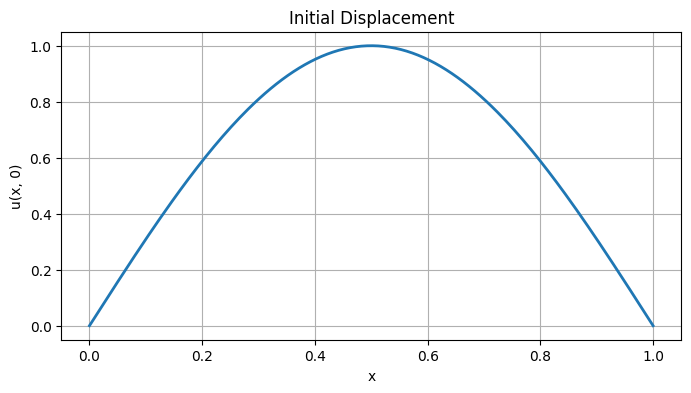

In [ ]:
# Analytical Solution

def analytical_solution(x, t, c=c):
    """
    Analytical solution of the 1D wave equation.

    u(x,t) = sin(pi*x) * cos(pi*c*t)
    """
    return np.sin(np.pi * x) * np.cos(np.pi * c * t)

# Quick verification
x_test = np.linspace(0, L, 200)
t_test = 0.0

u_initial = analytical_solution(x_test, t_test)

plt.figure(figsize=(8, 4))
plt.plot(x_test, u_initial, linewidth=2)
plt.xlabel("x")
plt.ylabel("u(x, 0)")
plt.title("Initial Displacement")
plt.grid(True)
plt.show()

# PINN Formulation

The PINN approximates the unknown solution using a neural network

$$
u_\theta(x,t),
$$

where $\theta$ represents all trainable neural-network parameters.

The neural network receives the coordinates

$$
(x,t)
$$

as inputs and returns the predicted displacement

$$
u_\theta(x,t).
$$

The PINN does not require the analytical solution during training.

Instead, automatic differentiation is used to calculate

$$
u_t,\quad
u_{tt},\quad
u_x,\quad
u_{xx}.
$$

These derivatives are then substituted into the governing PDE.

The resulting residual is

$$
r_\theta(x,t)
=
u_{\theta,tt}
-
c^2u_{\theta,xx}.
$$

# Import Deep Learning Framework

We use **PyTorch** because it provides automatic differentiation through its `autograd` system.

Automatic differentiation is one of the key components that makes PINNs possible.

Instead of manually deriving the neural-network derivatives, PyTorch computes them directly with respect to the input coordinates.

In [ ]:
# Import PyTorch

import torch
import torch.nn as nn

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Device selection
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("PyTorch version:", torch.__version__)
print("Using device:", device)

PyTorch version: 2.11.0+cpu
Using device: cpu


# Neural Network Architecture

The PINN is implemented as a fully connected feed-forward neural network.

The architecture is

$$
(x,t)
\rightarrow
\text{Dense}
\rightarrow
\tanh
\rightarrow
\text{Dense}
\rightarrow
\tanh
\rightarrow
\cdots
\rightarrow
\text{Dense}
\rightarrow
u_\theta.
$$

The input dimension is 2:

$$
(x,t).
$$

The output dimension is 1:

$$
u_\theta(x,t).
$$

We use the hyperbolic tangent activation function because smooth activation functions are particularly useful for PINNs, where higher-order derivatives of the network output are required.

# PINN Neural Network

In [ ]:
# PINN Neural Network

class WavePINN(nn.Module):

    def __init__(self, input_dim=2, hidden_dim=64, hidden_layers=4, output_dim=1):
        super().__init__()

        layers = []

        # Input layer
        layers.append(nn.Linear(input_dim, hidden_dim))
        layers.append(nn.Tanh())

        # Hidden layers
        for _ in range(hidden_layers - 1):
            layers.append(nn.Linear(hidden_dim, hidden_dim))
            layers.append(nn.Tanh())

        # Output layer
        layers.append(nn.Linear(hidden_dim, output_dim))

        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)

# Create model
model = WavePINN(input_dim=2, hidden_dim=64, hidden_layers=4, output_dim=1).to(device)

print(model)

WavePINN(
  (network): Sequential(
    (0): Linear(in_features=2, out_features=64, bias=True)
    (1): Tanh()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): Tanh()
    (4): Linear(in_features=64, out_features=64, bias=True)
    (5): Tanh()
    (6): Linear(in_features=64, out_features=64, bias=True)
    (7): Tanh()
    (8): Linear(in_features=64, out_features=1, bias=True)
  )
)


# Parameter Count

Before training, we inspect the number of trainable parameters in the PINN.

This provides a simple sanity check and helps document the computational complexity of the model.

In [ ]:
# Count Trainable Parameters

total_parameters = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print(f"Total trainable parameters: {total_parameters:,}")

Total trainable parameters: 12,737


# Collocation Points

PINNs require points inside the PDE domain where the governing equation is enforced.

These points are called **collocation points** or **residual points**.

For the interior domain,

$$
0<x<L,
\qquad
0<t<T.
$$

At each collocation point, the PINN evaluates

$$
r_\theta(x,t)
=
u_{tt}-c^2u_{xx}.
$$

No analytical solution is required at these points.

This is one of the defining characteristics of physics-informed learning.

In [ ]:
# Generate Interior Collocation Points

N_f = 10000

x_f = np.random.uniform(0.0, L, (N_f, 1))

t_f = np.random.uniform(0.0, T, (N_f, 1))

X_f_np = np.hstack([x_f, t_f])

# Store as a plain tensor.
# requires_grad will be enabled freshly during training.
X_f = torch.tensor(X_f_np, dtype=torch.float32, device=device)

print("Number of collocation points:", N_f)
print("Collocation tensor shape:", X_f.shape)

Number of collocation points: 10000
Collocation tensor shape: torch.Size([10000, 2])


# Initial Condition Points

The initial displacement condition is enforced at

$$
t=0.
$$

We sample points along the entire spatial domain.

The target displacement is

$$
u(x,0)=\sin(\pi x).
$$

The initial velocity condition is

$$
u_t(x,0)=0.
$$

In [ ]:
# Initial Condition Points

N_ic = 500

x_ic = np.linspace(0.0, L, N_ic).reshape(-1, 1)

t_ic = np.zeros_like(x_ic)

X_ic_np = np.hstack([x_ic, t_ic])

# Plain tensor
X_ic = torch.tensor(X_ic_np, dtype=torch.float32, device=device)

# Target initial displacement
u_ic = torch.sin(torch.pi * X_ic[:, 0:1])

# Detach target from any computation graph
u_ic = u_ic.detach()

# Target initial velocity
v_ic = torch.zeros_like(u_ic)

print("Initial-condition points:", N_ic)

Initial-condition points: 500


# Boundary Condition Points

The fixed-end conditions are

$$
u(0,t)=0
$$

and

$$
u(L,t)=0.
$$

We therefore sample temporal points along both boundaries.

The two boundary losses will be evaluated separately so that training diagnostics can identify whether either boundary is being poorly satisfied.

In [ ]:
# Boundary Condition Points

N_bc = 500

t_bc = np.linspace(0.0, T, N_bc).reshape(-1, 1)

# Left boundary: x = 0

X_bc_left_np = np.hstack([np.zeros_like(t_bc), t_bc])

# Right boundary: x = L

X_bc_right_np = np.hstack([L * np.ones_like(t_bc), t_bc])

# Convert to tensors
X_bc_left = torch.tensor(X_bc_left_np, dtype=torch.float32, device=device)

X_bc_right = torch.tensor(X_bc_right_np, dtype=torch.float32, device=device)

# Boundary targets
u_bc_left = torch.zeros((N_bc, 1), dtype=torch.float32, device=device)

u_bc_right = torch.zeros((N_bc, 1), dtype=torch.float32, device=device)

print("Boundary points per side:", N_bc)

Boundary points per side: 500


# Automatic Differentiation

The key PINN operation is the computation of derivatives of the neural-network output with respect to its inputs.

For

$$
u_\theta(x,t),
$$

we need

$$
u_x,\quad
u_{xx},\quad
u_t,\quad
u_{tt}.
$$

These derivatives are obtained using PyTorch automatic differentiation.

The second derivatives require applying automatic differentiation twice.

In [ ]:
# PDE Residual

def pde_residual(model, X):

    # Network prediction

    u = model(X)

    # First derivatives

    gradients = torch.autograd.grad(outputs=u, inputs=X, grad_outputs=torch.ones_like(u), create_graph=True, retain_graph=True)[0]

    u_x = gradients[:, 0:1]
    u_t = gradients[:, 1:2]

    # Second spatial derivative

    u_xx = torch.autograd.grad(outputs=u_x, inputs=X, grad_outputs=torch.ones_like(u_x), create_graph=True, retain_graph=True)[0][:, 0:1]

    # Second temporal derivative

    u_tt = torch.autograd.grad(outputs=u_t, inputs=X, grad_outputs=torch.ones_like(u_t), create_graph=True, retain_graph=True)[0][:, 1:2]

    # Wave equation residual

    residual = (u_tt - c**2 * u_xx)

    return residual

# Loss Function

The total PINN loss consists of five components.

### PDE loss

$$
\mathcal{L}_{PDE}
=
MSE(r_\theta,0)
$$

### Initial displacement loss

$$
\mathcal{L}_{IC,u}
=
MSE(u_\theta(x,0),u_0(x))
$$

### Initial velocity loss

$$
\mathcal{L}_{IC,v}
=
MSE(u_{\theta,t}(x,0),v_0(x))
$$

### Left boundary loss

$$
\mathcal{L}_{BC,L}
=
MSE(u_\theta(0,t),0)
$$

### Right boundary loss

$$
\mathcal{L}_{BC,R}
=
MSE(u_\theta(L,t),0)
$$

The total loss is

$$
\mathcal{L}
=
\mathcal{L}_{PDE}
+
\mathcal{L}_{IC,u}
+
\mathcal{L}_{IC,v}
+
\mathcal{L}_{BC,L}
+
\mathcal{L}_{BC,R}.
$$

In [ ]:
# PINN Loss Function

mse_loss = nn.MSELoss()

def compute_losses(model):

    # FRESH COLLOCATION GRAPH

    X_f_train = (X_f.detach().clone().requires_grad_(True))

    residual = pde_residual(model, X_f_train)

    loss_pde = mse_loss(residual, torch.zeros_like(residual))

    # FRESH INITIAL CONDITION GRAPH

    X_ic_train = (X_ic.detach().clone().requires_grad_(True))

    u_pred_ic = model(X_ic_train)

    loss_ic_u = mse_loss(u_pred_ic, u_ic)

    # INITIAL VELOCITY

    gradients_ic = torch.autograd.grad(
        outputs=u_pred_ic,
        inputs=X_ic_train,
        grad_outputs=torch.ones_like(u_pred_ic),
        create_graph=True,
        retain_graph=True
    )[0]

    u_t_ic = gradients_ic[:, 1:2]

    loss_ic_v = mse_loss(u_t_ic, v_ic)

    # FRESH LEFT BOUNDARY GRAPH

    X_bc_left_train = (X_bc_left.detach().clone().requires_grad_(True))

    u_left = model(X_bc_left_train)

    loss_bc_left = mse_loss(u_left, u_bc_left)

    # FRESH RIGHT BOUNDARY GRAPH

    X_bc_right_train = (X_bc_right.detach().clone().requires_grad_(True))

    u_right = model(X_bc_right_train)

    loss_bc_right = mse_loss(u_right, u_bc_right)

    # TOTAL LOSS

    total_loss = (loss_pde + loss_ic_u + loss_ic_v + loss_bc_left + loss_bc_right)

    return (total_loss, loss_pde,loss_ic_u, loss_ic_v, loss_bc_left, loss_bc_right)

In [ ]:
# Initialize PINN Model

model = WavePINN(input_dim=2, hidden_dim=64, hidden_layers=4, output_dim=1).to(device)

print(model)

WavePINN(
  (network): Sequential(
    (0): Linear(in_features=2, out_features=64, bias=True)
    (1): Tanh()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): Tanh()
    (4): Linear(in_features=64, out_features=64, bias=True)
    (5): Tanh()
    (6): Linear(in_features=64, out_features=64, bias=True)
    (7): Tanh()
    (8): Linear(in_features=64, out_features=1, bias=True)
  )
)


# Optimizer Configuration

We first train the PINN using the Adam optimizer.

Adam is useful for rapidly reducing the initial error and moving the network toward a good region of the parameter space.

After Adam training, a second optimization stage using L-BFGS can be used for refinement.

In [ ]:
# Adam Optimizer

learning_rate = 1e-3

optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

print("Optimizer:", optimizer.__class__.__name__)
print("Learning rate:", learning_rate)

Optimizer: Adam
Learning rate: 0.001


# Training Configuration

The following training configuration is used for the initial PINN experiment.

The individual loss terms are stored throughout training so that the optimization process can be analyzed later.

We intentionally monitor each component rather than only the total loss.

In [ ]:
# Training Configuration

epochs = 5000

history = {"total": [], "pde": [], "ic_u": [], "ic_v": [], "bc_left": [], "bc_right": []}

print("Training epochs:", epochs)

Training epochs: 5000


# Adam Training

The PINN is now trained by minimizing the total physics-informed loss.

At every iteration:

1. The network predicts $u_\theta(x,t)$.
2. Automatic differentiation computes the required derivatives.
3. The PDE residual is evaluated.
4. Initial and boundary condition errors are calculated.
5. All loss components are combined.
6. Adam updates the network parameters.

In [ ]:
# Adam Training Loop

for epoch in range(1, epochs + 1):

    # Parameter gradients

    optimizer.zero_grad(set_to_none=True)

    # Compute PINN losses
    (total_loss, loss_pde, loss_ic_u, loss_ic_v, loss_bc_left, loss_bc_right) = compute_losses(model)

    # Backpropagation

    total_loss.backward()

    # Update neural-network parameters

    optimizer.step()

    # Store losses

    history["total"].append(total_loss.item())

    history["pde"].append(loss_pde.item())

    history["ic_u"].append(loss_ic_u.item())

    history["ic_v"].append(loss_ic_v.item())

    history["bc_left"].append(loss_bc_left.item())

    history["bc_right"].append(loss_bc_right.item())

    # Progress display

    if epoch == 1 or epoch % 500 == 0:

        print(
            f"Epoch {epoch:5d} | "
            f"Total: {total_loss.item():.3e} | "
            f"PDE: {loss_pde.item():.3e} | "
            f"IC-u: {loss_ic_u.item():.3e} | "
            f"IC-v: {loss_ic_v.item():.3e} | "
            f"BC: "
            f"{(loss_bc_left + loss_bc_right).item():.3e}"
        )

Epoch     1 | Total: 3.910e-01 | PDE: 5.293e-05 | IC-u: 3.636e-01 | IC-v: 2.616e-05 | BC: 2.732e-02
Epoch   500 | Total: 5.228e-03 | PDE: 1.256e-03 | IC-u: 2.130e-04 | IC-v: 2.625e-03 | BC: 1.133e-03
Epoch  1000 | Total: 2.426e-03 | PDE: 5.688e-04 | IC-u: 1.124e-04 | IC-v: 1.642e-03 | BC: 1.031e-04
Epoch  1500 | Total: 1.706e-03 | PDE: 2.618e-04 | IC-u: 9.816e-05 | IC-v: 1.307e-03 | BC: 3.950e-05
Epoch  2000 | Total: 1.262e-03 | PDE: 1.089e-04 | IC-u: 9.235e-05 | IC-v: 1.012e-03 | BC: 4.852e-05
Epoch  2500 | Total: 9.216e-04 | PDE: 6.265e-05 | IC-u: 8.413e-05 | IC-v: 7.140e-04 | BC: 6.086e-05
Epoch  3000 | Total: 6.424e-04 | PDE: 4.467e-05 | IC-u: 7.525e-05 | IC-v: 4.487e-04 | BC: 7.375e-05
Epoch  3500 | Total: 4.641e-04 | PDE: 4.156e-05 | IC-u: 7.457e-05 | IC-v: 2.581e-04 | BC: 8.983e-05
Epoch  4000 | Total: 1.272e-03 | PDE: 1.269e-04 | IC-u: 1.928e-04 | IC-v: 7.654e-04 | BC: 1.865e-04
Epoch  4500 | Total: 1.031e-03 | PDE: 1.329e-04 | IC-u: 1.283e-04 | IC-v: 3.125e-04 | BC: 4.577e-04


## Training History

A successful PINN training process should show a substantial reduction in the total loss and in the individual physics-based loss components.

We visualize the training history using a logarithmic scale because PINN losses can span several orders of magnitude.

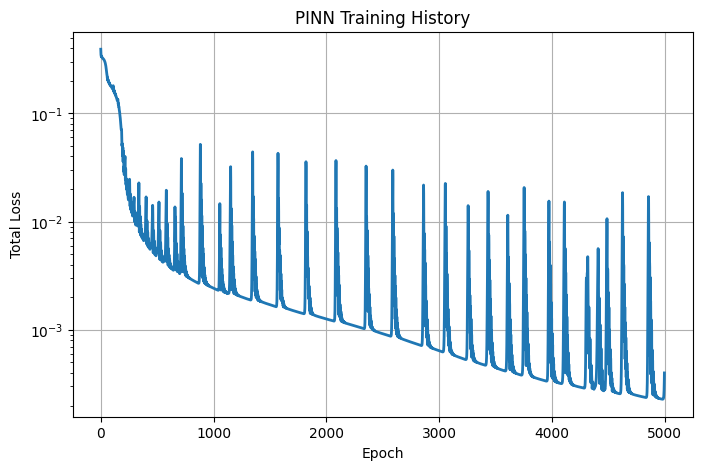

In [ ]:
# Plot Total Loss

plt.figure(figsize=(8, 5))

plt.semilogy(history["total"], linewidth=2)

plt.xlabel("Epoch")
plt.ylabel("Total Loss")
plt.title("PINN Training History")
plt.grid(True)

plt.show()

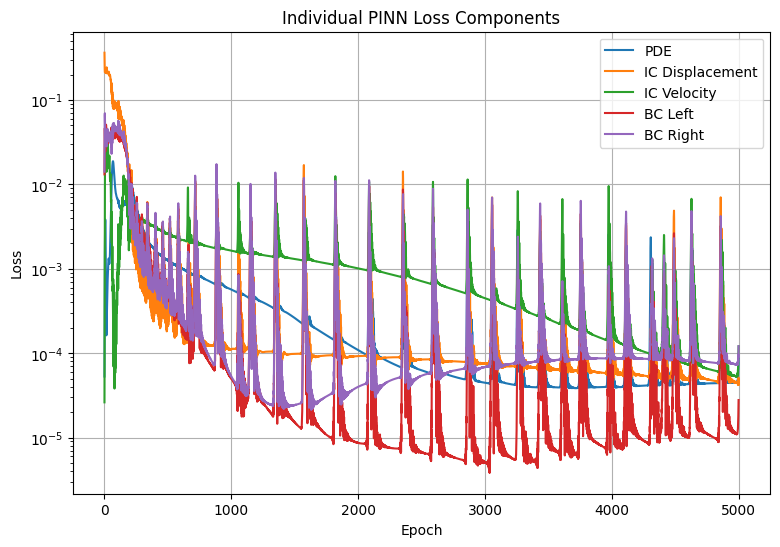

In [ ]:
# Plot Individual Loss Components

plt.figure(figsize=(9, 6))

plt.semilogy(history["pde"], label="PDE")

plt.semilogy(history["ic_u"], label="IC Displacement")

plt.semilogy(history["ic_v"], label="IC Velocity")

plt.semilogy(history["bc_left"], label="BC Left")

plt.semilogy(history["bc_right"], label="BC Right")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Individual PINN Loss Components")
plt.legend()
plt.grid(True)

plt.show()

# PINN Prediction

After training, the neural network can be evaluated at arbitrary $(x,t)$ coordinates.

This means that the trained PINN represents a continuous approximation

$$
u_\theta(x,t)
$$

of the wave field over the entire space-time domain.

In [ ]:
# Create Evaluation Grid

Nx = 200
Nt = 200

x_eval = np.linspace(0.0, L, Nx)

t_eval = np.linspace(0.0, T, Nt)

X_grid, T_grid = np.meshgrid(x_eval, t_eval)

X_flat = X_grid.reshape(-1, 1)
T_flat = T_grid.reshape(-1, 1)

XT_flat = np.hstack([X_flat, T_flat])

XT_tensor = torch.tensor(XT_flat, dtype=torch.float32, device=device)

# Prediction
with torch.no_grad():

    U_pred = model(XT_tensor).cpu().numpy()

U_pred = U_pred.reshape(Nt, Nx)

print("Prediction shape:", U_pred.shape)

Prediction shape: (200, 200)


# Analytical Solution on the Evaluation Grid

For validation, we evaluate the analytical solution on the same space-time grid used by the PINN.

This ensures that the PINN and analytical solutions are compared at identical coordinates.

In [ ]:
# Exact Solution

U_exact = analytical_solution(X_grid, T_grid, c=c)

print("Exact solution shape:", U_exact.shape)

Exact solution shape: (200, 200)


# PINN vs Analytical Solution

We now visualize the complete space-time wave field predicted by the PINN.

The horizontal axis represents position $x$ and the vertical axis represents time $t$.

The wave should propagate and reflect in a manner consistent with the analytical solution.

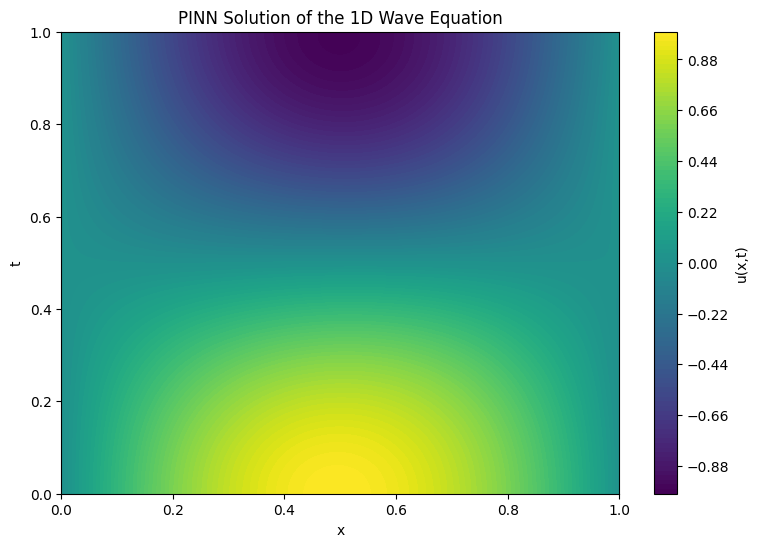

In [ ]:
# PINN Solution

plt.figure(figsize=(9, 6))

plt.contourf(X_grid, T_grid, U_pred, levels=100)

plt.colorbar(label="u(x,t)")

plt.xlabel("x")
plt.ylabel("t")
plt.title("PINN Solution of the 1D Wave Equation")

plt.show()

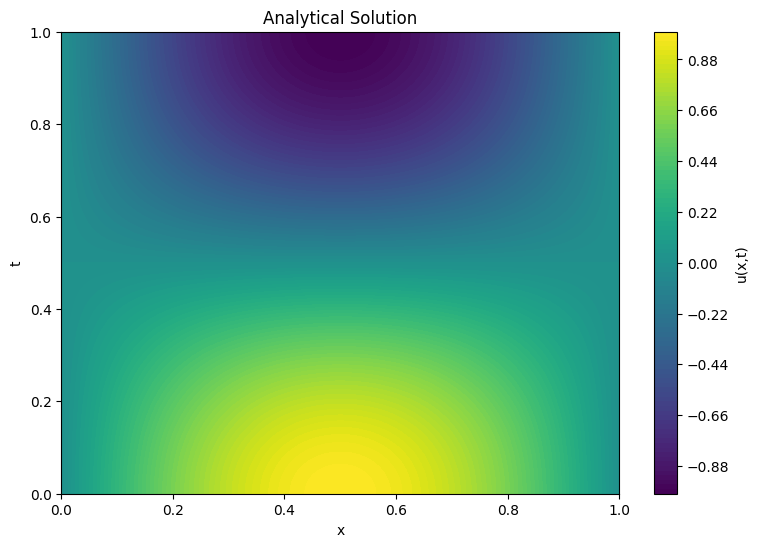

In [ ]:
# Analytical Solution

plt.figure(figsize=(9, 6))

plt.contourf(X_grid, T_grid, U_exact, levels=100)

plt.colorbar(label="u(x,t)")

plt.xlabel("x")
plt.ylabel("t")
plt.title("Analytical Solution")

plt.show()

# Absolute Error Analysis

The pointwise absolute error is defined as

$$
e(x,t)
=
\left|
u_{\theta}(x,t)
-
u_{\text{exact}}(x,t)
\right|.
$$

A spatial-temporal error map provides a detailed view of where the PINN has the largest prediction error.

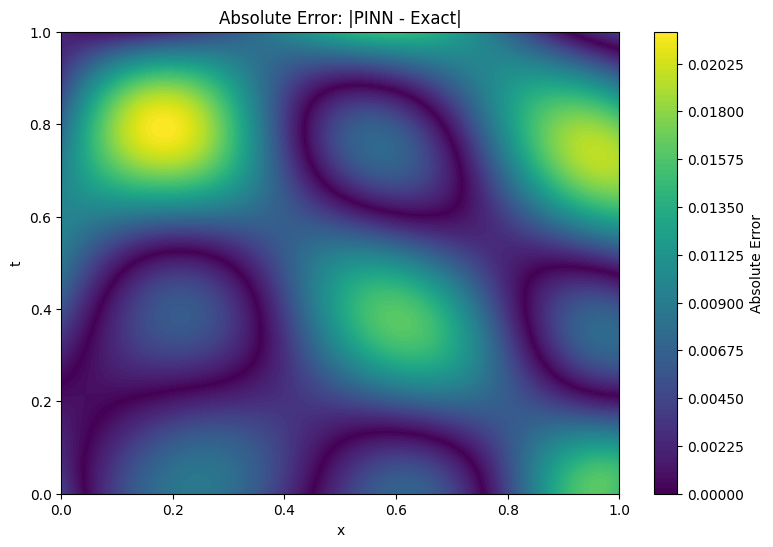

In [ ]:
# Absolute Error

absolute_error = np.abs(U_pred - U_exact)

plt.figure(figsize=(9, 6))

plt.contourf(X_grid, T_grid, absolute_error, levels=100)

plt.colorbar(label="Absolute Error")

plt.xlabel("x")
plt.ylabel("t")
plt.title("Absolute Error: |PINN - Exact|")

plt.show()

# Quantitative Error Metrics

We use multiple metrics to evaluate the trained PINN.

### Mean Squared Error

$$
MSE
=
\frac{1}{N}
\sum_{i=1}^{N}
(u_i^{PINN}-u_i^{exact})^2
$$

### Root Mean Squared Error

$$
RMSE
=
\sqrt{MSE}
$$

### Relative $L_2$ Error

$$
L_2^{rel}
=
\frac{
\|u_{PINN}-u_{exact}\|_2
}{
\|u_{exact}\|_2
}.
$$

These metrics provide complementary information about the global accuracy of the PINN.

In [ ]:
# Error Metrics

error = U_pred - U_exact

mse = np.mean(error**2)

rmse = np.sqrt(mse)

relative_l2_error = (np.linalg.norm(error)/np.linalg.norm(U_exact))

max_absolute_error = np.max(np.abs(error))

print(f"MSE                  : {mse:.6e}")
print(f"RMSE                 : {rmse:.6e}")
print(f"Relative L2 Error    : {relative_l2_error:.6e}")
print(f"Maximum Absolute Error: {max_absolute_error:.6e}")

MSE                  : 7.196544e-05
RMSE                 : 8.483245e-03
Relative L2 Error    : 1.696670e-02
Maximum Absolute Error: 2.172913e-02


# Wave Profiles at Selected Times

A global heatmap is useful, but line plots at selected time instances provide a more intuitive comparison.

We compare the PINN and analytical solutions at several time levels:

$$
t=0,\quad
0.25,\quad
0.50,\quad
0.75,\quad
1.0.
$$

The agreement between the two curves provides a direct visual validation of the learned wave dynamics.

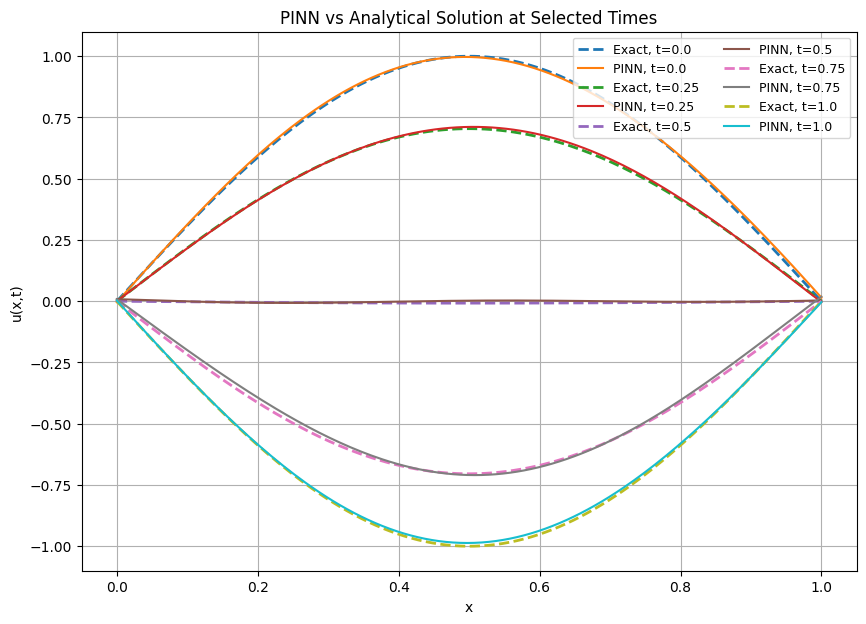

In [ ]:
# Time-Slice Comparison

selected_times = [0.0, 0.25, 0.50, 0.75, 1.0]

plt.figure(figsize=(10, 7))

for t_value in selected_times:

    time_index = np.argmin(np.abs(t_eval - t_value))

    plt.plot(x_eval, U_exact[time_index], linestyle="--", linewidth=2, label=f"Exact, t={t_value}")

    plt.plot(x_eval, U_pred[time_index], linewidth=1.5, label=f"PINN, t={t_value}")

plt.xlabel("x")
plt.ylabel("u(x,t)")
plt.title("PINN vs Analytical Solution at Selected Times")

plt.legend(ncol=2, fontsize=9)

plt.grid(True)
plt.show()

# Physics Residual Validation

A low prediction error alone does not guarantee that the neural network has learned the governing physics.

Therefore, we independently evaluate the PDE residual:

$$
r_\theta(x,t)
=
u_{tt}-c^2u_{xx}.
$$

For a successful PINN,

$$
r_\theta(x,t)\approx0.
$$

This provides a direct test of whether the learned solution satisfies the governing wave equation.

In [ ]:
# PDE Residual Evaluation

XT_residual = torch.tensor(XT_flat, dtype=torch.float32, device=device, requires_grad=True)

residual = pde_residual(model, XT_residual)

residual_np = (residual.detach().cpu().numpy().reshape(Nt, Nx))

residual_abs = np.abs(residual_np)

print("Mean absolute PDE residual:", np.mean(residual_abs))

print("Maximum absolute PDE residual:", np.max(residual_abs))

Mean absolute PDE residual: 0.008605093
Maximum absolute PDE residual: 0.04288715


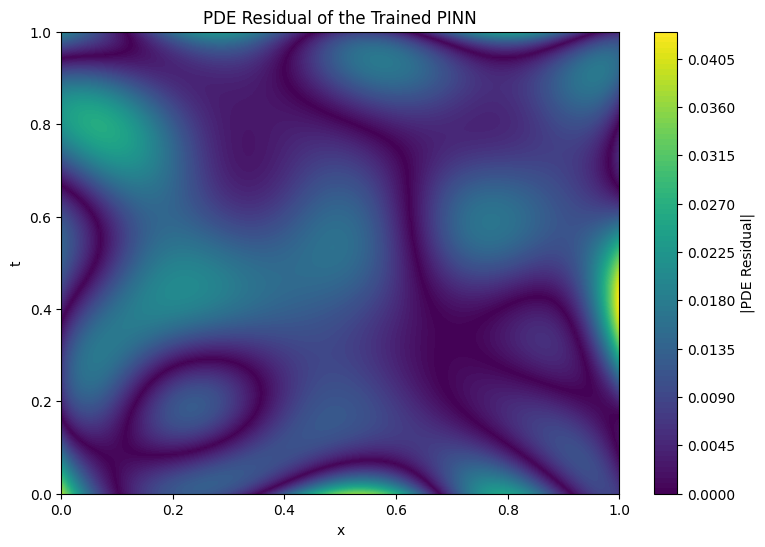

In [ ]:
# PDE Residual Map

plt.figure(figsize=(9, 6))

plt.contourf(X_grid, T_grid, residual_abs, levels=100)

plt.colorbar(label="|PDE Residual|")

plt.xlabel("x")
plt.ylabel("t")
plt.title("PDE Residual of the Trained PINN")

plt.show()

# Boundary Condition Validation

We now explicitly verify the fixed-end conditions.

The required conditions are

$$
u(0,t)=0
$$

and

$$
u(1,t)=0.
$$

The predicted boundary displacement should remain close to zero for the entire time interval.

In [ ]:
# Boundary Validation

X_left_eval = np.column_stack([np.zeros_like(t_eval), t_eval])

X_right_eval = np.column_stack([L * np.ones_like(t_eval), t_eval])

X_left_tensor = torch.tensor(X_left_eval, dtype=torch.float32, device=device)

X_right_tensor = torch.tensor(X_right_eval, dtype=torch.float32, device=device)

with torch.no_grad():

    u_left_pred = (model(X_left_tensor).cpu().numpy().flatten())

    u_right_pred = (model(X_right_tensor).cpu().numpy().flatten())

print("Maximum left-boundary error:", np.max(np.abs(u_left_pred)))

print("Maximum right-boundary error:", np.max(np.abs(u_right_pred)))

Maximum left-boundary error: 0.0097985715
Maximum right-boundary error: 0.01904016


# Initial Condition Validation

The trained PINN must reproduce both initial conditions.

### Initial displacement

$$
u(x,0)=\sin(\pi x)
$$

### Initial velocity

$$
u_t(x,0)=0.
$$

We validate both conditions independently.

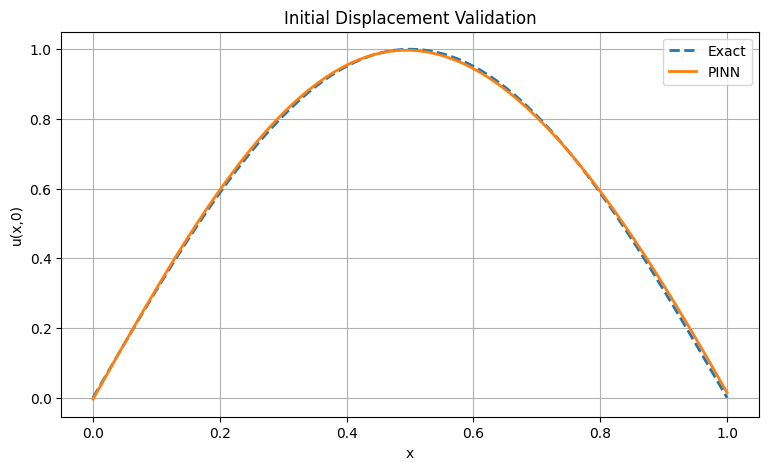

In [ ]:
# Initial Displacement Validation

X_initial_eval = np.column_stack([x_eval, np.zeros_like(x_eval)])

X_initial_tensor = torch.tensor(X_initial_eval, dtype=torch.float32, device=device, requires_grad=True)

u_initial_pred = model(X_initial_tensor)

initial_grads = torch.autograd.grad(
    outputs=u_initial_pred,
    inputs=X_initial_tensor,
    grad_outputs=torch.ones_like(u_initial_pred),
    create_graph=False
)[0]

u_initial_pred_np = (u_initial_pred.detach().cpu().numpy().flatten())

u_initial_velocity_np = (initial_grads[:, 1].detach().cpu().numpy())

u_initial_exact = np.sin(np.pi * x_eval)

plt.figure(figsize=(9, 5))

plt.plot(x_eval,u_initial_exact,"--", linewidth=2, label="Exact")

plt.plot(x_eval, u_initial_pred_np, linewidth=2, label="PINN")

plt.xlabel("x")
plt.ylabel("u(x,0)")
plt.title("Initial Displacement Validation")
plt.legend()
plt.grid(True)

plt.show()

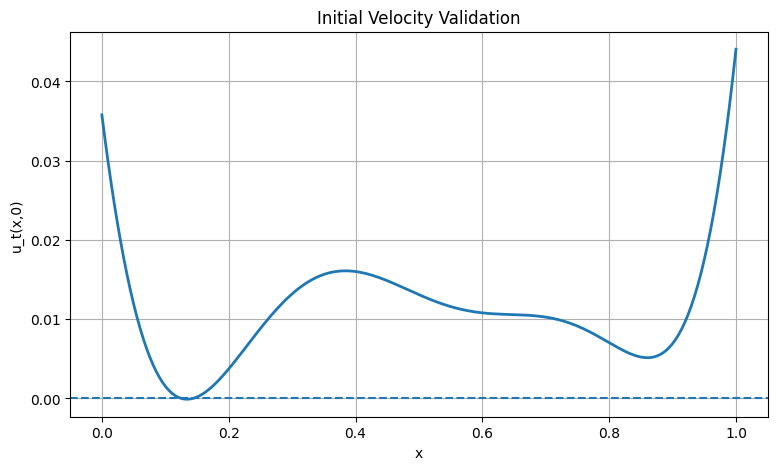

Maximum initial velocity error: 0.04406771


In [ ]:
# Initial Velocity Validation

plt.figure(figsize=(9, 5))

plt.plot(x_eval, u_initial_velocity_np, linewidth=2)

plt.axhline(0.0, linestyle="--", linewidth=1.5)

plt.xlabel("x")
plt.ylabel("u_t(x,0)")
plt.title("Initial Velocity Validation")
plt.grid(True)

plt.show()

print("Maximum initial velocity error:", np.max(np.abs(u_initial_velocity_np)))

# Energy-Based Physical Interpretation

For the ideal one-dimensional wave equation without damping or external forcing, the total mechanical energy should remain approximately constant.

The energy density is related to

$$
\frac{1}{2}u_t^2
+
\frac{c^2}{2}u_x^2.
$$

Therefore, the total energy can be approximated numerically as

$$
E(t)
=
\int_0^L
\left[
\frac{1}{2}u_t^2
+
\frac{c^2}{2}u_x^2
\right]dx.
$$

This provides an additional physics-based validation of the PINN solution.

In [ ]:
# Energy Evaluation

def compute_energy(model, t_value, nx=500):

    x = np.linspace(0.0, L, nx).reshape(-1, 1)

    t = np.full_like(x, t_value)

    XT = np.hstack([x, t])

    XT_tensor = torch.tensor(XT, dtype=torch.float32, device=device, requires_grad=True)

    u = model(XT_tensor)

    grads = torch.autograd.grad(
        outputs=u,
        inputs=XT_tensor,
        grad_outputs=torch.ones_like(u),
        create_graph=False
    )[0]

    u_x = grads[:, 0].detach().cpu().numpy().flatten()
    u_t = grads[:, 1].detach().cpu().numpy().flatten()

    energy_density = (0.5 * u_t**2 + 0.5 * c**2 * u_x**2)

    energy = np.trapezoid(energy_density, x.flatten())

    return energy

energy_values = np.array([compute_energy(model, t_value) for t_value in t_eval])

print("Initial energy:", energy_values[0])
print("Final energy:", energy_values[-1])

Initial energy: 2.446017869376737
Final energy: 2.412088335218293


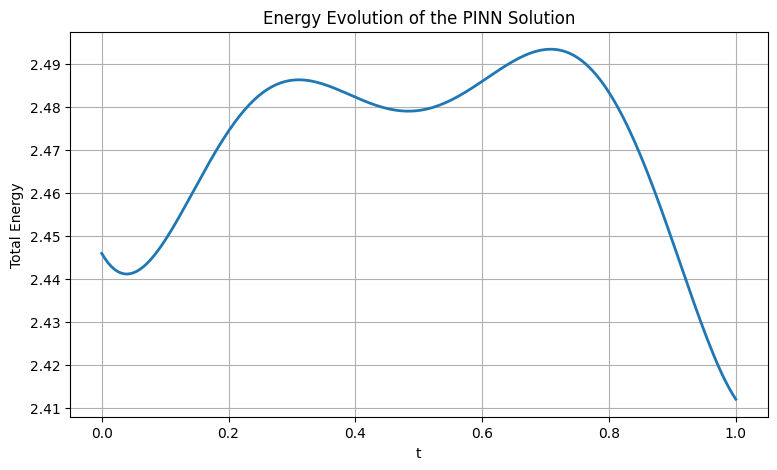

In [ ]:
# Energy Conservation Plot

plt.figure(figsize=(9, 5))

plt.plot(t_eval, energy_values, linewidth=2)

plt.xlabel("t")
plt.ylabel("Total Energy")
plt.title("Energy Evolution of the PINN Solution")
plt.grid(True)

plt.show()

# Final Model Performance Summary

The PINN has now been evaluated from several complementary perspectives:

### Numerical accuracy

- MSE
- RMSE
- Relative $L_2$ error
- Maximum absolute error

### Physics consistency

- PDE residual
- Initial displacement condition
- Initial velocity condition
- Boundary conditions
- Energy conservation

A reliable PINN should demonstrate both low numerical error and strong satisfaction of the governing physical constraints.

In [ ]:
# Final Performance Summary

mean_pde_residual = np.mean(residual_abs)

max_pde_residual = np.max(residual_abs)

max_bc_error = max(
    np.max(np.abs(u_left_pred)),
    np.max(np.abs(u_right_pred))
)

max_ic_velocity_error = np.max(np.abs(u_initial_velocity_np))

energy_variation = ((np.max(energy_values) - np.min(energy_values)) / np.mean(energy_values))

print("=" * 60)
print("           PINN PERFORMANCE SUMMARY")
print("=" * 60)

print(f"MSE                         : {mse:.6e}")
print(f"RMSE                        : {rmse:.6e}")
print(f"Relative L2 Error           : {relative_l2_error:.6e}")
print(f"Maximum Absolute Error      : {max_absolute_error:.6e}")
print(f"Mean PDE Residual           : {mean_pde_residual:.6e}")
print(f"Maximum PDE Residual        : {max_pde_residual:.6e}")
print(f"Maximum Boundary Error      : {max_bc_error:.6e}")
print(f"Maximum Initial Velocity Err: {max_ic_velocity_error:.6e}")
print(f"Relative Energy Variation   : {energy_variation:.6e}")

print("=" * 60)

           PINN PERFORMANCE SUMMARY
MSE                         : 7.196544e-05
RMSE                        : 8.483245e-03
Relative L2 Error           : 1.696670e-02
Maximum Absolute Error      : 2.172913e-02
Mean PDE Residual           : 8.605093e-03
Maximum PDE Residual        : 4.288715e-02
Maximum Boundary Error      : 1.904016e-02
Maximum Initial Velocity Err: 4.406771e-02
Relative Energy Variation   : 3.294459e-02


# Conclusions

In this notebook, a Physics-Informed Neural Network was developed to solve the one-dimensional wave equation.

The PINN was trained using:

- the governing wave equation,
- the initial displacement,
- the initial velocity,
- the fixed-end boundary conditions.

The analytical solution was used only for validation.

The trained PINN was evaluated using both numerical and physics-based diagnostics, including:

1. Space-time solution comparison
2. Absolute error
3. MSE
4. RMSE
5. Relative $L_2$ error
6. PDE residual
7. Boundary-condition error
8. Initial-condition error
9. Energy conservation

This establishes a complete forward-PINN workflow for a classical hyperbolic PDE.

# Future Extensions

The present implementation provides a foundation for more advanced PINN research.

Possible extensions include:

### Improved Sampling

Compare:

- Uniform random sampling
- Latin Hypercube Sampling
- Sobol sampling
- Adaptive residual-based sampling

### Adaptive Loss Weighting

Instead of

$$
\lambda_i=1,
$$

learn or dynamically adjust the relative importance of different loss components.

### Hard Constraint PINNs

Embed the boundary conditions directly into the neural-network representation.

### Inverse PINNs

Treat the wave speed $c$ as an unknown trainable parameter.

### Noisy Measurements

Train the PINN using sparse and noisy observations.

### Damped Wave Equation

Extend the governing equation to

$$
u_{tt}
+
\gamma u_t
=
c^2u_{xx}.
$$

### Forced Wave Equation

Consider

$$
u_{tt}
-
c^2u_{xx}
=
f(x,t).
$$

### Two-Dimensional Wave Equation

Extend the formulation to

$$
u_{tt}
=
c^2
\left(
u_{xx}+u_{yy}
\right).
$$

### Physics-Informed Surrogate Modeling

Investigate whether a trained neural operator or surrogate can efficiently approximate wave dynamics across varying physical parameters.

### Research-Level Problems

Potential directions include:

- nonlinear wave equations,
- heterogeneous media,
- acoustic wave propagation,
- elastic wave propagation,
- inverse parameter estimation,
- uncertainty quantification,
- multi-fidelity physics-informed learning.

# Key Takeaway

The fundamental PINN workflow can be summarized as

$$
\boxed{
(x,t)
\rightarrow
u_\theta(x,t)
\rightarrow
\{u_t,u_{tt},u_x,u_{xx}\}
\rightarrow
r_\theta
\rightarrow
\mathcal{L}
\rightarrow
\text{Optimization}
}
$$

The neural network is therefore not simply fitting a dataset.

Instead, it learns a solution that simultaneously attempts to satisfy:

$$
\boxed{
\text{PDE}
+
\text{Initial Conditions}
+
\text{Boundary Conditions}
}
$$

This is the central idea behind Physics-Informed Neural Networks.